![PCOS](https://img-cdn.medkomtek.com/J_Q2GT78W2CZQO8GFX8s0L_AEUI=/0x0/smart/filters:quality(100):format(webp)/article/nv-LVYH1oNKCXGkGGZR86/original/038160000_1569585751-7-Hal-tentang-PCOS-yang-Perlu-Diketahui-Wanita-By-CHEN-I-CHUN-Shutterstock.jpg)

**Polycystic Ovary Syndrome (PCOS)** adalah gangguan hormonal yang umum terjadi pada wanita usia reproduktif. Gejala PCOS bervariasi dan dapat mencakup siklus menstruasi yang tidak teratur, infertilitas, jerawat, peningkatan berat badan, serta gangguan metabolisme. Mengingat dampaknya baik fisik maupun psikologis, diagnosis dini sangat penting untuk pengobatan yang tepat.

Dengan kemajuan teknologi dan machine learning, proyek ini bertujuan untuk mengembangkan model untuk mendiagnosis PCOS berdasarkan dataset medis, meningkatkan deteksi dini dan manajemen kesehatan wanita.

**Problem Statements**
- Gejala PCOS bervariasi antar individu, menyulitkan dokter dalam membuat diagnosis yang akurat.
- Akses terbatas ke spesialis di daerah pedesaan menghambat diagnosis yang tepat waktu.
- Metode diagnosis PCOS sering memakan waktu dan bergantung pada interpretasi subjektif.
- Terdapat tantangan dalam menganalisis data medis yang tidak lengkap atau tidak terstruktur dengan baik.

**Goals**
- Menggunakan machine learning untuk mendeteksi PCOS lebih cepat dan akurat, memungkinkan diagnosis dini.
- Mengidentifikasi pola tersembunyi dalam gejala PCOS untuk diagnosis yang lebih personal.
- Mengembangkan alat berbasis machine learning yang dapat diakses oleh praktisi kesehatan umum atau pasien, memperluas akses diagnosis PCOS di daerah dengan keterbatasan.
- Menangani ketidaklengkapan atau ketidakteraturan data medis menggunakan teknik machine learning.

**Solution Statements**
- Menggunakan algoritma regresi logistik untuk memprediksi kemungkinan PCOS berdasarkan faktor risiko seperti BMI, kadar insulin, dan riwayat kesehatan keluarga.
- Melakukan hyperparameter tuning pada model untuk meningkatkan performa, dengan teknik seperti Grid Search atau Random Search.
- Menerapkan pohon keputusan untuk memahami hubungan antara variabel medis dan membantu dalam diagnosis PCOS.

In [255]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Data Understanding

Dataset yang digunakan dalam proyek ini adalah [PCOS Diagnosis Dataset](https://www.kaggle.com/datasets/samikshadalvi/pcos-diagnosis-dataset) yang berisi data medis terkait PCOS dari Kaggle, yang berisi data terkait pasien dengan Polycystic Ovary Syndrome (PCOS). Dataset ini terdiri dari 1000 entri yang mewakili pasien, dengan lima fitur utama yang sering digunakan dalam diagnosis dan penilaian risiko PCOS.

Variabel-variabel pada Restaurant UCI dataset adalah sebagai berikut:
- **Age** (years): Usia pasien dalam tahun, dengan rentang dari 18 hingga 45 tahun.
- **BMI** (kg/m²): Indeks Massa Tubuh (Body Mass Index) pasien, yang merupakan ukuran lemak tubuh berdasarkan tinggi dan berat, dengan rentang dari 18 hingga 35.
- **Menstrual Irregularity** (binary): Indikator biner yang menunjukkan apakah pasien mengalami siklus menstruasi yang tidak teratur (0 = Tidak, 1 = Ya).
- **Testosterone Level** (ng/dL): Tingkat testosteron dalam darah pasien, indikator hormonal penting dari PCOS, dengan rentang dari 20 hingga 100 ng/dL.
- **Antral Follicle Count**: Jumlah folikel antral yang terdeteksi selama ultrasonografi, dengan rentang dari 5 hingga 30, yang membantu dalam menilai cadangan ovarium dan keberadaan PCOS.
- **PCOS Diagnosis** (binary): Indikator biner yang menunjukkan apakah pasien telah didiagnosis dengan PCOS (0 = Tidak, 1 = Ya), berdasarkan kombinasi faktor risiko seperti BMI tinggi, kadar testosteron, ketidakteraturan menstruasi, dan jumlah folikel antral. **(Variabel Target)**

In [256]:
data = pd.read_csv('pcos_dataset.csv')
data.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [257]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


### Tahapan Exploratory Data Analysis (EDA) dan Visualisasi Data:
- Distribusi Data: Visualisasi distribusi masing-masing fitur (seperti distribusi BMI, usia, dan kadar testosteron) untuk memahami variasi dan pola dalam dataset.
- Missing Data: Memeriksa keberadaan data yang hilang dan menangani masalah tersebut melalui imputasi atau penghapusan data yang tidak lengkap.
- Outliers: Deteksi dan penanganan outlier, terutama pada fitur numerik seperti BMI dan testosteron, yang dapat mempengaruhi akurasi model.
- Korelasi antar Fitur: Menggunakan heatmap untuk melihat korelasi antara fitur-fitur yang ada, seperti apakah ada hubungan signifikan antara BMI dan kadar testosteron, atau antara jumlah folikel antral dan irregularitas menstruasi.

#### Distribusi Data

In [258]:
data.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.771000,26.38700,0.530000,60.159500,17.469000,0.199000
std,8.463462,4.93554,0.499349,23.160204,7.069301,0.399448
min,18.000000,18.10000,0.000000,20.000000,5.000000,0.000000
25%,24.000000,21.90000,0.000000,41.700000,12.000000,0.000000
50%,32.000000,26.40000,1.000000,60.000000,18.000000,0.000000
75%,39.000000,30.50000,1.000000,80.300000,23.250000,0.000000
max,45.000000,35.00000,1.000000,99.800000,29.000000,1.000000


In [259]:
#  Kolom numerik 
numerical_cols = ['Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']
#  Kolom kategori binary 
binary_cols = ['Menstrual_Irregularity', 'PCOS_Diagnosis']

In [260]:
# Distribusi data per kolom
print("\nDistribusi Data:")
for col in binary_cols:
    print(data[col].value_counts())


Distribusi Data:
Menstrual_Irregularity
1    530
0    470
Name: count, dtype: int64
PCOS_Diagnosis
0    801
1    199
Name: count, dtype: int64


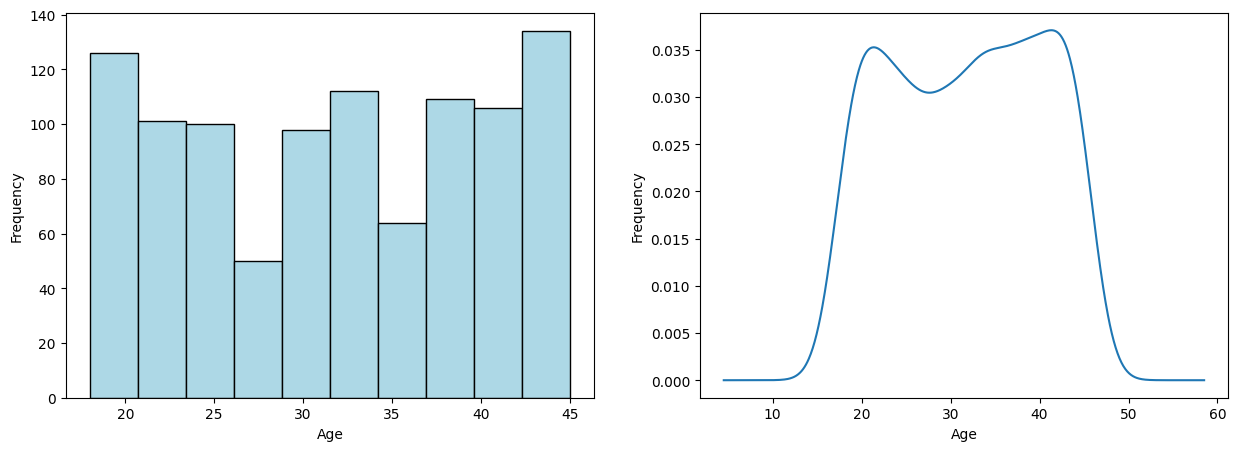

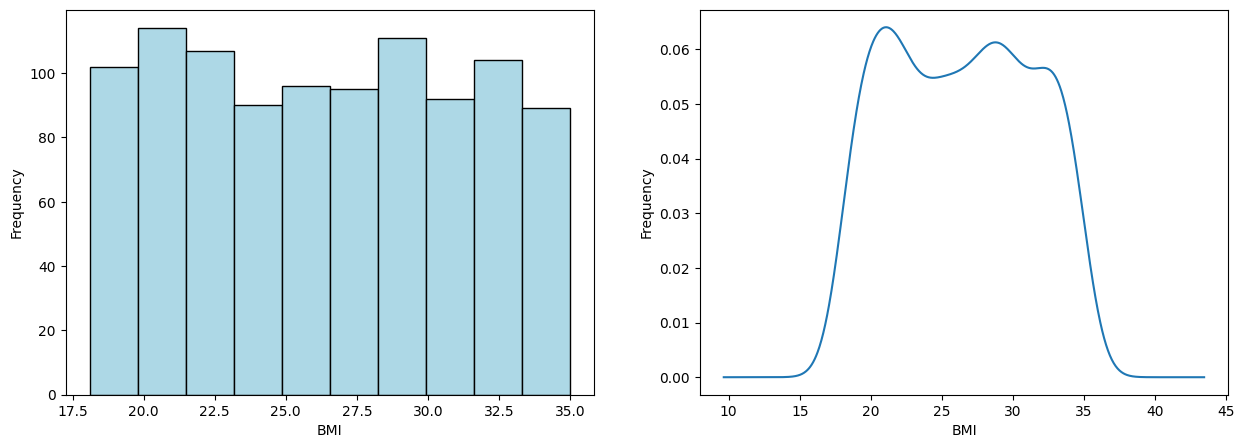

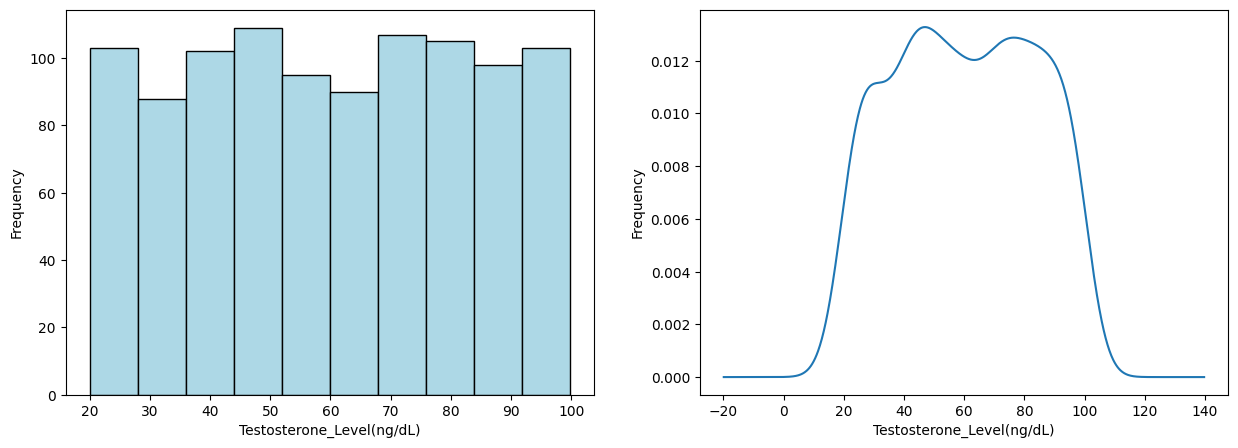

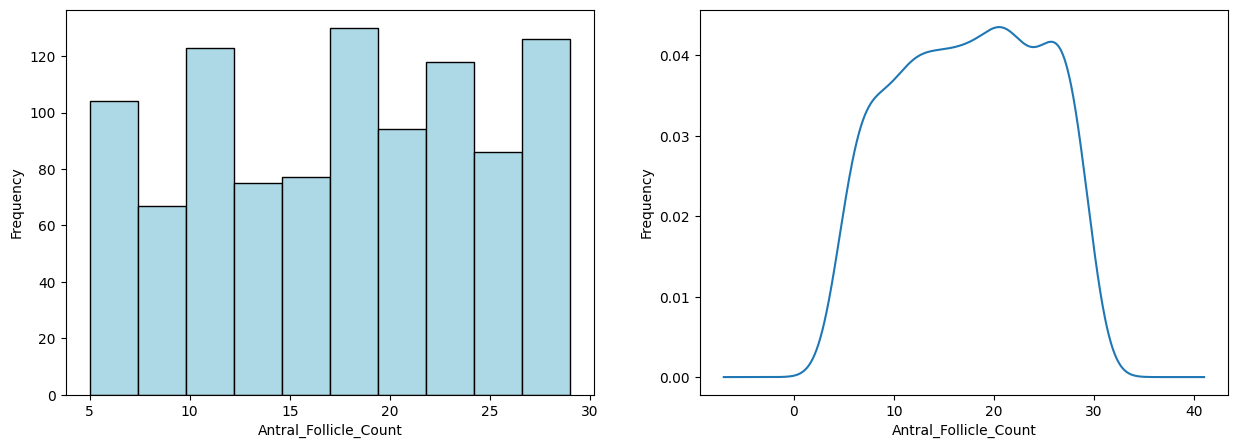

In [261]:
for col in numerical_cols:
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    data[col].plot(kind='hist',edgecolor='black',color='lightblue')
    plt.ylabel('Frequency')
    plt.xlabel(col)
    
    plt.subplot(1,2,2)
    data[col].plot(kind='kde')
    plt.ylabel('Frequency')
    plt.xlabel(col)

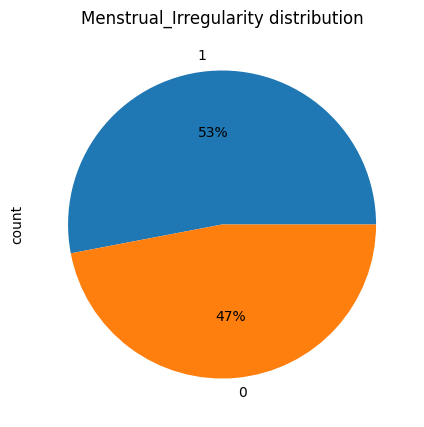

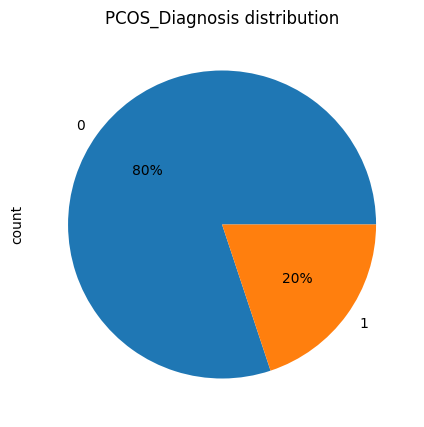

In [262]:
for col in binary_cols:
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    data[col].value_counts().plot(kind='pie',autopct='%1.0f%%')
    plt.title(f'{col} distribution')

dari data dapat ditemukan bahwa diagnosis cenderung ke tidak terdiagnosis dengan perbandingan data mencapai 8:2. 

##### Missing Value

In [263]:
# Mengecek jumlah data NaN
data.isna().sum()

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64

In [264]:
# Mengecek jumlah data Null
data.isnull().sum()

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64


Tidak ditemukan data yang hilang (missing value)

#### Outliers

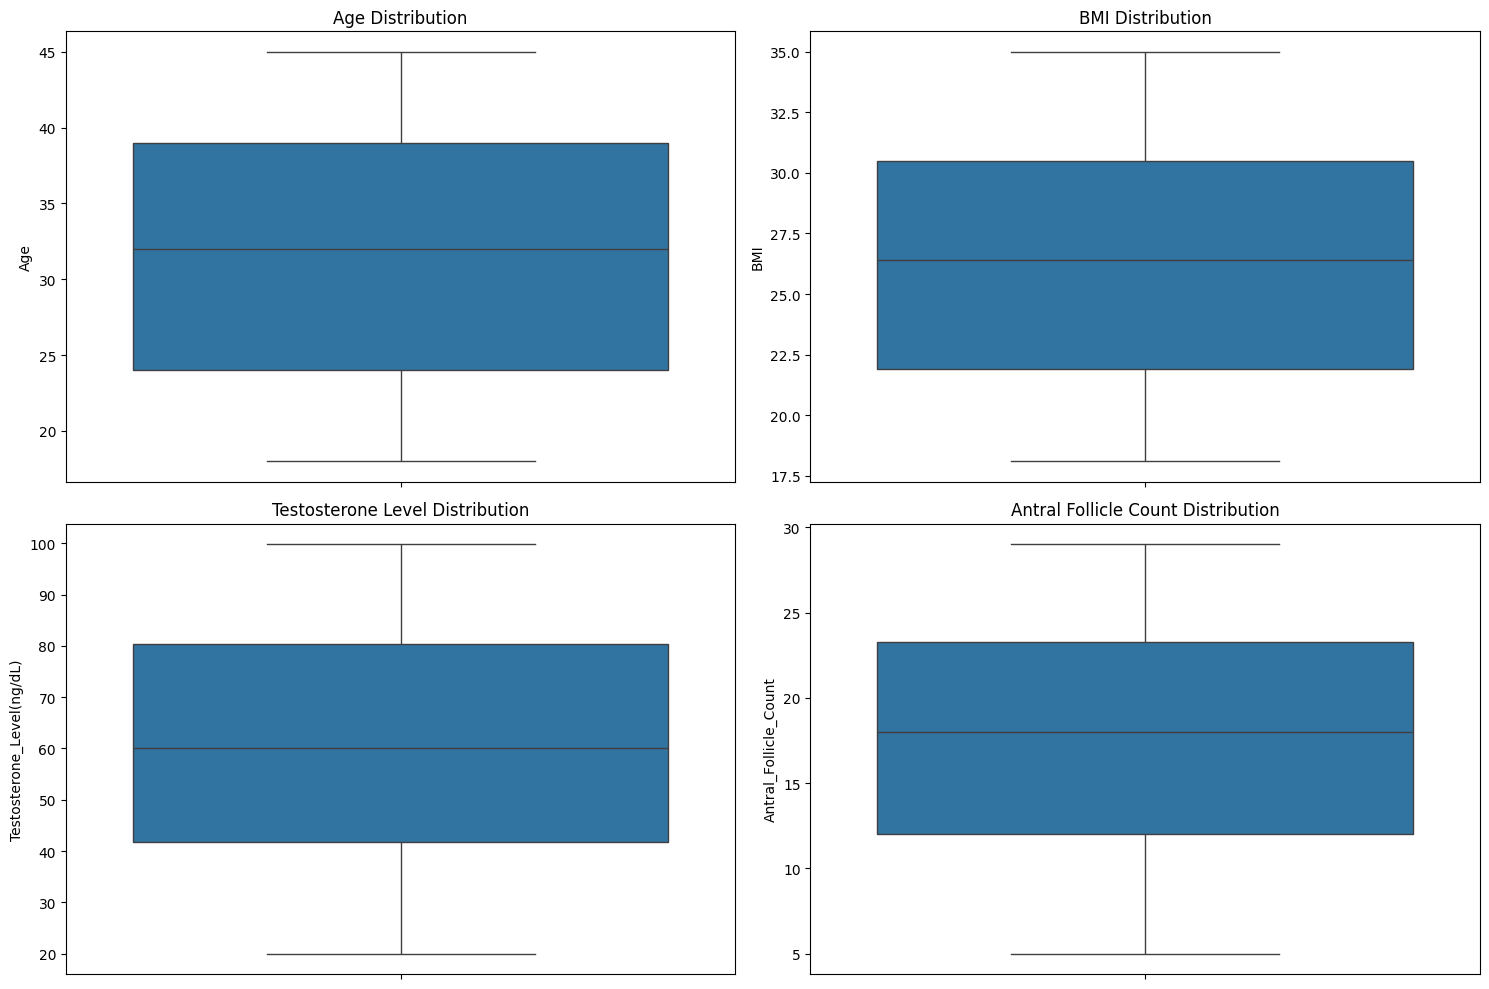

In [265]:
# Mengecek outliers dengan boxplot
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(y=data['Age'])
plt.title('Age Distribution')

plt.subplot(2, 2, 2)
sns.boxplot(y=data['BMI'])
plt.title('BMI Distribution')

plt.subplot(2, 2, 3)
sns.boxplot(y=data['Testosterone_Level(ng/dL)'])
plt.title('Testosterone Level Distribution')

plt.subplot(2, 2, 4)
sns.boxplot(y=data['Antral_Follicle_Count'])
plt.title('Antral Follicle Count Distribution')

plt.tight_layout()
plt.show()

In [266]:
# Mengecek dengan metode Quartile
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return len(outliers)

for col in numerical_cols:
    outlier_count = detect_outliers(data, col)
    print(f'Number of outliers in {col}: {outlier_count}')


Number of outliers in Age: 0
Number of outliers in BMI: 0
Number of outliers in Testosterone_Level(ng/dL): 0
Number of outliers in Antral_Follicle_Count: 0


Tidak ditemukan data yang diluar jangkauan (outlier)

#### Kolerasi Data

##### Bivariate

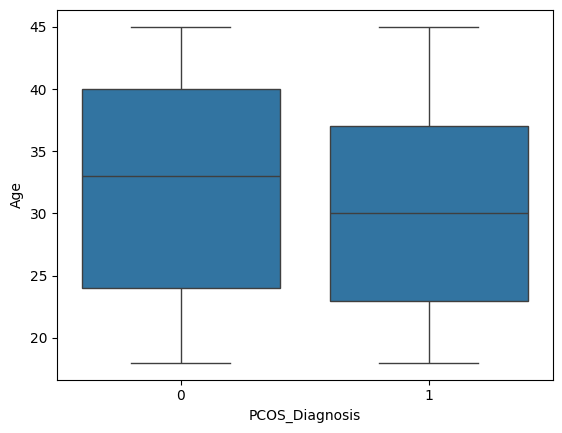

In [267]:
sns.boxplot(x='PCOS_Diagnosis', y='Age', data=data)
plt.show()

In [268]:
bmi_mean=data.groupby('PCOS_Diagnosis')['BMI'].mean()
bmi_mean

PCOS_Diagnosis
0    25.457928
1    30.126633
Name: BMI, dtype: float64

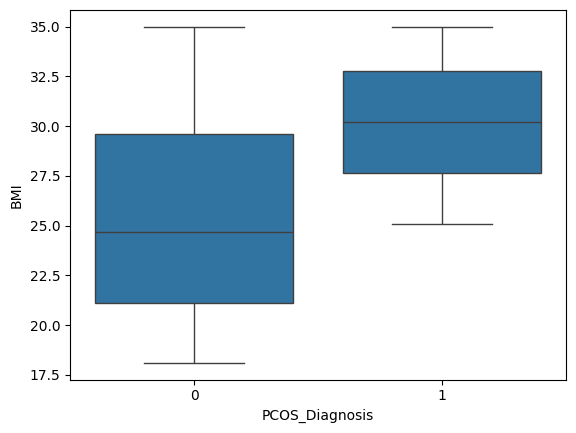

In [269]:
sns.boxplot(x='PCOS_Diagnosis', y='BMI', data=data)
plt.show()

Pasien yang terdiagnosis dengan PCOS memiliki BMI lebih dari 25.0 lg/m2, yaitu diatas batas normal (18.01 sampai 25.0 kg/m2)

In [270]:
T_mean=data.groupby('PCOS_Diagnosis')['Testosterone_Level(ng/dL)'].mean()
T_mean

PCOS_Diagnosis
0    57.842447
1    69.485930
Name: Testosterone_Level(ng/dL), dtype: float64

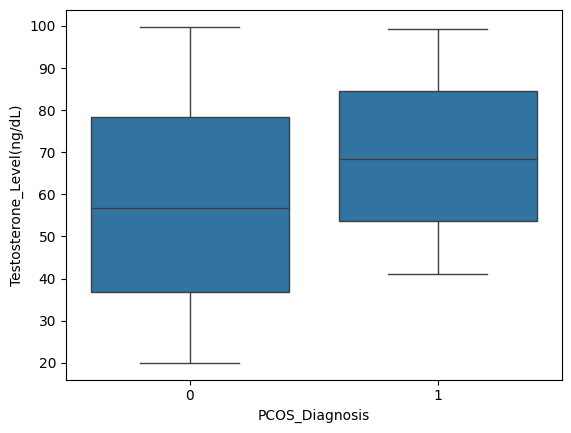

In [271]:
sns.boxplot(x='PCOS_Diagnosis', y='Testosterone_Level(ng/dL)', data=data)
plt.show()

In [272]:
AFC_count=data.groupby('PCOS_Diagnosis')['Antral_Follicle_Count'].mean()
AFC_count



PCOS_Diagnosis
0    16.792759
1    20.190955
Name: Antral_Follicle_Count, dtype: float64

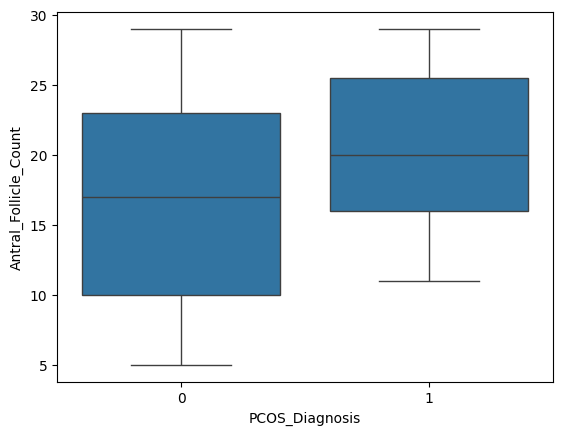

In [273]:
sns.boxplot(x='PCOS_Diagnosis', y='Antral_Follicle_Count', data=data)
plt.show()

In [274]:
cross=pd.crosstab(data['Menstrual_Irregularity'],data['PCOS_Diagnosis'])
cross

PCOS_Diagnosis,0,1
Menstrual_Irregularity,,
0,470,0
1,331,199


Pasien yang terdiagnosis PCOS mengalami siklus menstruasi yang tidak teratur

##### Multivariate

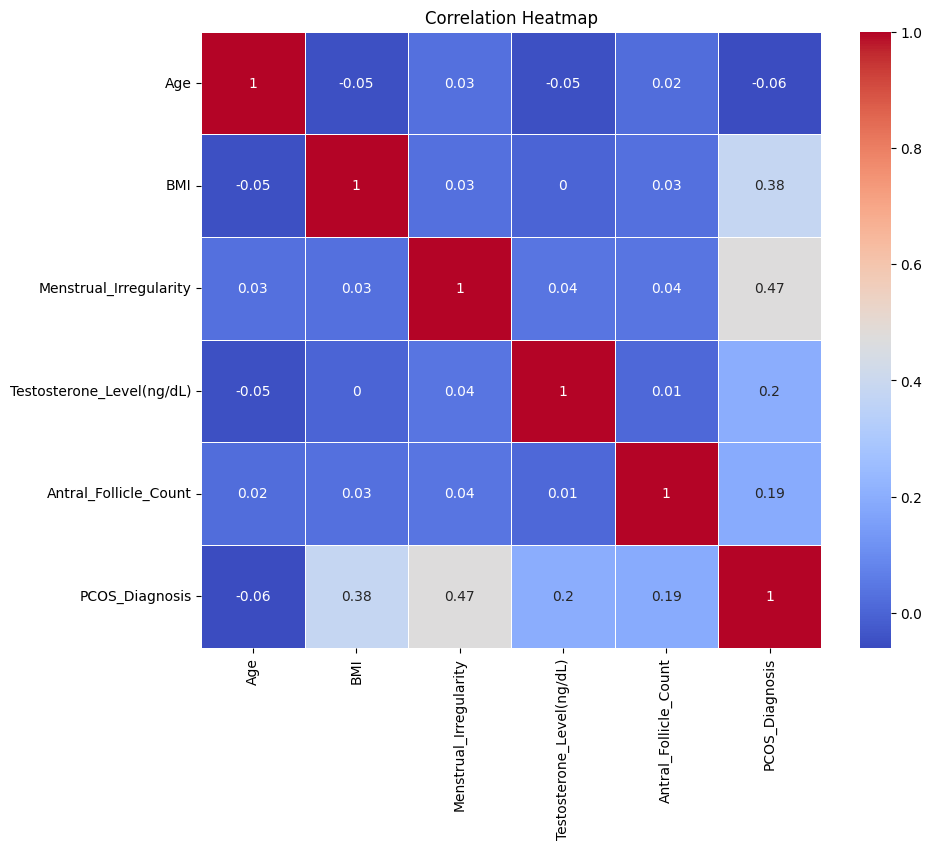

In [275]:
# Menggunakan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr().round(2), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Dari heatmap, fitur yang paling signifikan terhadap PCOS_Diagnosis yaitu Menstrual_Irregularity dan BMI. 

# Data Preparation

### Handling Unbalance Data

Proses ini dilakukan untuk mengurangi bias yang terjadi akibat kurangnya data yang menyatakan pasien terdiagnosis PCOS. 

In [276]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

feature_names = data.columns.tolist()
feature_names.remove('PCOS_Diagnosis')

X_resampled, y_resampled = smote.fit_resample(data[feature_names], data['PCOS_Diagnosis'])

# membuat data baru
data_balanced = pd.DataFrame(X_resampled, columns=feature_names)
data_balanced['PCOS_Diagnosis'] = y_resampled

print("Original class distribution:")
print(data['PCOS_Diagnosis'].value_counts())
print("\nBalanced class distribution:")
print(data_balanced['PCOS_Diagnosis'].value_counts())

# mengganti data asli dengan data baru
data = data_balanced

Original class distribution:
PCOS_Diagnosis
0    801
1    199
Name: count, dtype: int64

Balanced class distribution:
PCOS_Diagnosis
0    801
1    801
Name: count, dtype: int64


c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


### Splitting Data

 Dataset dibagi menjadi 80% data pelatihan dan 20% data pengujian atau validation data untuk lebih menilai kinerja model

In [277]:
X = data.drop(["PCOS_Diagnosis"],axis =1)
y = data["PCOS_Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)

print(f'Shape of training data: {X_train.shape}')
print(f'Shape of test data: {X_test.shape}')

Shape of training data: (1281, 5)
Shape of test data: (321, 5)


### Normalisasi

In [278]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelling

### Regresi Logistik

In [279]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_y_train_pred = lr.predict(X_train_scaled)
lr_y_test_pred = lr.predict(X_test_scaled)

print("Accuracy Score : " , accuracy_score(y_test,lr_y_test_pred))

cv_scores = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
print("Mean Cross-validation scores:", np.mean(cv_scores))

c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Accuracy Score :  0.4672897196261682
Mean Cross-validation scores: 0.9070015576323988


In [280]:
# Hypertuning parameter
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

grid_search = GridSearchCV(estimator=lr,
                         param_grid=param_grid, 
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

lr = grid_search.best_estimator_

lr_y_train_pred = lr.predict(X_train_scaled)
lr_y_test_pred = lr.predict(X_test_scaled)

Best parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.9125790369649807


c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Decision Tree

In [281]:
dt = DecisionTreeClassifier(random_state=123)
dt.fit(X_train_scaled, y_train)

dt_y_train_pred = dt.predict(X_train_scaled)
dt_y_test_pred = dt.predict(X_test_scaled)

print("Accuracy Score : " , accuracy_score(y_test,dt_y_test_pred))

cv_scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy')
print("Mean Cross-validation scores:", np.mean(cv_scores))

Accuracy Score :  0.4672897196261682
Mean Cross-validation scores: 0.9993769470404985


c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [282]:
# Hypertuning parameter
dt = DecisionTreeClassifier(random_state=123)

param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=dt, 
                         param_grid=param_grid,
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

dt = grid_search.best_estimator_

dt_y_train_pred = dt.predict(X_train_scaled)
dt_y_test_pred = dt.predict(X_test_scaled)

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation accuracy: 0.99921875


c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Random Forest

In [283]:
rf = RandomForestClassifier(random_state=123)
rf.fit(X_train_scaled, y_train)

rf_y_train_pred = rf.predict(X_train_scaled)
rf_y_test_pred = rf.predict(X_test_scaled)

print("Accuracy Score : " , accuracy_score(y_test, rf_y_test_pred))

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Mean Cross-validation scores:", np.mean(cv_scores))

c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Accuracy Score :  0.4672897196261682
Mean Cross-validation scores: 0.9993769470404985


In [284]:
# Hypertuning parameter
rf = RandomForestClassifier(random_state=123)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(estimator=rf,
                         param_grid=param_grid, 
                         cv=5,
                         scoring='accuracy',
                         n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

rf = grid_search.best_estimator_

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy: 0.99921875


In [285]:
rf_y_train_pred = rf.predict(X_train_scaled)
rf_y_test_pred = rf.predict(X_test_scaled)

c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### XGBoost


In [286]:
xg = XGBClassifier(random_state=123)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

grid_search = GridSearchCV(estimator=xg,
                         param_grid=param_grid,
                         cv=5, 
                         scoring='accuracy',
                         n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

xg = grid_search.best_estimator_

xg_y_train_pred = xg.predict(X_train_scaled)
xg_y_test_pred = xg.predict(X_test_scaled)


Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation accuracy: 0.99921875


# Evaluation

In [287]:
accuracy = pd.DataFrame(columns=['train_acc', 'test_acc'], 
                      index=['LR', 'DT', 'RF', 'XG'])
accuracy.loc['LR', 'train_acc'] = accuracy_score(y_train, lr_y_train_pred)
accuracy.loc['LR', 'test_acc'] = accuracy_score(y_test, lr_y_test_pred)

accuracy.loc['DT', 'train_acc'] = accuracy_score(y_train, dt_y_train_pred)
accuracy.loc['DT', 'test_acc'] = accuracy_score(y_test, dt_y_test_pred)

accuracy.loc['RF', 'train_acc'] = accuracy_score(y_train, rf_y_train_pred)
accuracy.loc['RF', 'test_acc'] = accuracy_score(y_test, rf_y_test_pred)

accuracy.loc['XG', 'train_acc'] = accuracy_score(y_train, xg_y_train_pred)
accuracy.loc['XG', 'test_acc'] = accuracy_score(y_test, xg_y_test_pred)

accuracy

,train_acc,test_acc
LR,0.911788,0.46729
DT,0.999219,0.46729
RF,1.0,0.46729
XG,1.0,0.46729


Decision Tree, Random Forest, dan XGBoost memiliki akurasi sempurna baik di data pelatihan maupun pengujian (100%).
Logistic Regression sedikit lebih rendah dibandingkan tiga model lainnya.

In [288]:
print('\nLogistic Regression')
print('Precision Score (Train):', precision_score(y_train, lr_y_train_pred))
print('Precision Score (Test):', precision_score(y_test, lr_y_test_pred))

print('\nDecision Tree')
print('Precision Score (Train):', precision_score(y_train, dt_y_train_pred))
print('Precision Score (Test):', precision_score(y_test, dt_y_test_pred))

print('\nRandom Forest')
print('Precision Score (Train):', precision_score(y_train, rf_y_train_pred))
print('Precision Score (Test):', precision_score(y_test, rf_y_test_pred))

print('\nXGBoost')
print('Precision Score (Train):', precision_score(y_train, xg_y_train_pred))
print('Precision Score (Test):', precision_score(y_test, xg_y_test_pred))



Logistic Regression
Precision Score (Train): 0.8983050847457628
Precision Score (Test): 0.0

Decision Tree
Precision Score (Train): 1.0
Precision Score (Test): 0.0

Random Forest
Precision Score (Train): 1.0
Precision Score (Test): 0.0

XGBoost
Precision Score (Train): 1.0
Precision Score (Test): 0.0


c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\reera\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Decision Tree, Random Forest, dan XGBoost menunjukkan Precision sempurna (100%) di kedua set data (train dan test).
Logistic Regression memiliki Precision yang lebih rendah dibandingkan tiga model lainnya.

In [289]:
print('\nLogistic Regression')
print('Recall Score (Train):', recall_score(y_train, lr_y_train_pred))
print('Recall Score (Test):', recall_score(y_test, lr_y_test_pred))

print('\nDecision Tree')
print('Recall Score (Train):', recall_score(y_train, dt_y_train_pred))
print('Recall Score (Test):', recall_score(y_test, dt_y_test_pred))

print('\nRandom Forest')
print('Recall Score (Train):', recall_score(y_train, rf_y_train_pred))
print('Recall Score (Test):', recall_score(y_test, rf_y_test_pred))

print('\nXGBoost')
print('Recall Score (Train):', recall_score(y_train, xg_y_train_pred))
print('Recall Score (Test):', recall_score(y_test, xg_y_test_pred))


Logistic Regression
Recall Score (Train): 0.9253968253968254
Recall Score (Test): 0.0

Decision Tree
Recall Score (Train): 0.9984126984126984
Recall Score (Test): 0.0

Random Forest
Recall Score (Train): 1.0
Recall Score (Test): 0.0

XGBoost
Recall Score (Train): 1.0
Recall Score (Test): 0.0


Decision Tree, Random Forest, dan XGBoost memiliki Recall sempurna (100%).
Logistic Regression sedikit lebih rendah, dengan Recall 96.03% di data pelatihan dan 92.40% di data pengujian.

In [290]:
print('\nLogistic Regression')
print('F1 Score (Train):', f1_score(y_train, lr_y_train_pred))
print('F1 Score (Test):', f1_score(y_test, lr_y_test_pred))

print('\nDecision Tree')
print('F1 Score (Train):', f1_score(y_train, dt_y_train_pred))
print('F1 Score (Test):', f1_score(y_test, dt_y_test_pred))

print('\nRandom Forest')
print('F1 Score (Train):', f1_score(y_train, rf_y_train_pred))
print('F1 Score (Test):', f1_score(y_test, rf_y_test_pred))

print('\nXGBoost')
print('F1 Score (Train):', f1_score(y_train, xg_y_train_pred))
print('F1 Score (Test):', f1_score(y_test, xg_y_test_pred))


Logistic Regression
F1 Score (Train): 0.9116497263487099
F1 Score (Test): 0.0

Decision Tree
F1 Score (Train): 0.9992057188244639
F1 Score (Test): 0.0

Random Forest
F1 Score (Train): 1.0
F1 Score (Test): 0.0

XGBoost
F1 Score (Train): 1.0
F1 Score (Test): 0.0


Decision Tree, Random Forest, dan XGBoost memiliki F1 Score sempurna (100%).
Logistic Regression sedikit lebih rendah dalam hal F1 Score.

In [291]:
print('\nLogistic Regression')
print('ROC AUC Score (Train):', roc_auc_score(y_train, lr_y_train_pred))
print('ROC AUC Score (Test):', roc_auc_score(y_test, lr_y_test_pred))

print('\nDecision Tree')
print('ROC AUC Score (Train):', roc_auc_score(y_train, dt_y_train_pred))
print('ROC AUC Score (Test):', roc_auc_score(y_test, dt_y_test_pred))

print('\nRandom Forest')
print('ROC AUC Score (Train):', roc_auc_score(y_train, rf_y_train_pred))
print('ROC AUC Score (Test):', roc_auc_score(y_test, rf_y_test_pred))

print('\nXGBoost')
print('ROC AUC Score (Train):', roc_auc_score(y_train, xg_y_train_pred))
print('ROC AUC Score (Test):', roc_auc_score(y_test, xg_y_test_pred))


Logistic Regression
ROC AUC Score (Train): 0.9120071684587814
ROC AUC Score (Test): 0.5

Decision Tree
ROC AUC Score (Train): 0.9992063492063492
ROC AUC Score (Test): 0.5

Random Forest
ROC AUC Score (Train): 1.0
ROC AUC Score (Test): 0.5

XGBoost
ROC AUC Score (Train): 1.0
ROC AUC Score (Test): 0.5


Decision Tree, Random Forest, dan XGBoost memiliki skor AUC sempurna (100%).
Logistic Regression sedikit lebih rendah dibandingkan tiga model lainnya.

## Hasil Evaluasi

- Decision Tree, Random Forest, dan XGBoost menunjukkan performa yang sangat baik di seluruh metrik evaluasi, dengan skor sempurna di Precision, Recall, F1 Score, dan ROC AUC baik di data pelatihan maupun pengujian.
- Logistic Regression memiliki performa lebih rendah dalam semua metrik dibandingkan dengan ketiga model lainnya, meskipun masih menunjukkan kinerja yang baik.
- Model yang dipilih yaitu **XGBoost** karena menawarkan performa terbaik dengan nilai 1.0 di semua metrik dan sering kali lebih unggul dalam hal generalisasi dan kinerja pada data yang lebih kompleks atau tidak seimbang, sementara Random Forest lebih robust terhadap overfitting dan bisa bekerja dengan baik di berbagai jenis data. 

In [292]:
model = xg